# Figure S4 (aggregated, flu-like candidates) — method comparison

Pools the **flu-like candidate runs** (`data/<batch>/antigen-outputs/candidate_runs.csv`) into a single
three-panel figure mirroring the manuscript reference figure:

- **A** — Number of Variants over time (panel D of the reference).
- **B** — Average Variance in Fitness over time (panel E).
- **C** — NID method-agreement distribution (the pooled analogue of the
  per-run bubble plots F/G).

The three assignment methods are overlaid with the reference colors. Each
center line is the **median** across candidate runs; the band is the IQR.
Median (not mean) is used because the within-run fitness variance is
right-skewed, which would otherwise push the mean outside its own IQR band.
The claim these support: *results are stable when you simulate a flu-like tree.*

## Two fitness models for panel B

Panel B is drawn twice, from the two aggregated tables that
`scripts/aggregate_results.py` emits with an identical schema:

| Output | Panel B source | Fitness model |
| --- | --- | --- |
| `figureS4_candidates_panel.{pdf,png}` | `host_immunity_variance_over_time.csv` | Risk of infection against **individual hosts' full immune histories** (min antigenic distance within each host's memory), from `out.histories.raw.csv`. |
| `figureS4_candidates_panel-centroids.{pdf,png}` | `fitness_variance_over_time.csv` | Distance to a single **population immune-memory centroid** per year, from `out.histories.csv`. The older approximation. |

Panels A and C are identical between the two. Only runs with an
`out.histories.raw.csv` contribute to the host-immunity table, so the two
figures may pool different numbers of runs — each reports its own `n`.

Figures are written to `figures/<batch>/`.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

# Styling and panel-letter placement come from antigentools.supplement_style
# so every supplement figure shares one definition. NOTE: this notebook used
# legend sizes 13/14 where S5 used 12/13; the shared module takes S5's, so
# legend text here shifts by one point.
from antigentools.supplement_style import apply_supplement_style, add_panel_letters, style_panel, seed_jitter

apply_supplement_style()

# --- parameters ---------------------------------------------------------
BATCH = '2026-07-04-reviewer-runs'
AGG_DIR = Path('..') / 'results' / 'aggregated' / BATCH
# Finalized figures live in the round1 review figures dir.
FIG_DIR = Path('..') / '..' / 'antigen-tex' / 'reviews' / 'round1' / 'figures'
CAND_PATH = Path('..') / 'data' / BATCH / 'antigen-outputs' / 'candidate_runs.csv'
MIN_YEAR_BIN = 0          # drop burn-in bins below this; None to keep all
COUNTS_BAND = False       # panel A: integer counts make the IQR band jagged;
                          # a clean median line reads better. Set True to shade.

METHODS = ['variant_ag', 'variant_tsne', 'variant_phylo']
METHOD_LABELS = {'variant_ag': 'antigenic', 'variant_tsne': 'sequence', 'variant_phylo': 'phylogenetic'}
# Match the reference figure's method colors.
METHOD_COLORS = {'variant_ag': '#1f77b4', 'variant_tsne': '#ff7f0e', 'variant_phylo': '#2ca02c'}

In [2]:
# --- candidate (config, run) filter ------------------------------------
cand = pd.read_csv(CAND_PATH)


def config_from_path(p):
    m = re.search(r'simulations/([^/]+)/run_', p)
    assert m is not None, f'cannot parse config from candidate path: {p!r}'
    return m.group(1)


cand['config'] = cand['path'].map(config_from_path)
cand_keys = set(zip(cand['config'], cand['run'].astype(int)))
print(f'{len(cand_keys)} flu-like candidate runs in {CAND_PATH.name}')


def keep_candidates(df, label):
    """Filter an aggregated table to the candidate (config, run) keys."""
    key = list(zip(df['config'], df['run'].astype(int)))
    mask = pd.Series([k in cand_keys for k in key], index=df.index)
    out = df[mask].copy()
    n_present = out.groupby(['config', 'run']).ngroups
    print(f'  {label}: {n_present}/{len(cand_keys)} candidate runs present, {len(out)} rows')
    return out

45 flu-like candidate runs in candidate_runs.csv


In [3]:
# --- load + filter aggregated tables -----------------------------------
counts_df = pd.read_csv(AGG_DIR / 'variant_counts_over_time.csv')
if MIN_YEAR_BIN is not None:
    counts_df = counts_df[counts_df['year_bin'] >= MIN_YEAR_BIN]
counts_df = keep_candidates(counts_df, 'variant counts')


def load_variance(filename, label):
    """Load one fitness-variance table and filter it to the candidate runs.

    Both fitness models emit the schema of ``calc_variance_over_time``
    (year, method, mean_variance, n_variants), so panel B is built identically
    whichever one produced the numbers.
    """
    df = pd.read_csv(AGG_DIR / filename)
    # method is 'ag'/'tsne'/'phylo'; canonicalize to 'variant_*' so panel B
    # shares panel A's colors/labels.
    df['method'] = df['method'].apply(
        lambda m: m if str(m).startswith('variant_') else f'variant_{m}'
    )
    if MIN_YEAR_BIN is not None:
        df = df[df['year'] >= MIN_YEAR_BIN]
    return keep_candidates(df, label)


# Panel B fitness model -> output filename suffix. The per-host immune-history
# model is the default (no suffix); the population-centroid approximation it
# replaces is written alongside it for comparison. Not every run has an
# out.histories.raw.csv, so the two can pool different numbers of runs -- each
# figure reports its own n rather than assuming they match.
VARIANCE_SOURCES = {
    '': ('host_immunity_variance_over_time.csv', 'fitness variance (host immunity)'),
    '-centroids': ('fitness_variance_over_time.csv', 'fitness variance (centroid)'),
}
variance_dfs = {
    suffix: load_variance(filename, label)
    for suffix, (filename, label) in VARIANCE_SOURCES.items()
}

nid_df = keep_candidates(pd.read_csv(AGG_DIR / 'method_agreement_nid.csv'), 'NID')

N_RUNS = counts_df.groupby(['config', 'run']).ngroups
print(f'pooling {N_RUNS} candidate runs (panels A/C)')
for suffix, df in variance_dfs.items():
    n = df.groupby(['config', 'run']).ngroups
    print(f"  panel B [{VARIANCE_SOURCES[suffix][0]}]: {n} runs")

  variant counts: 45/45 candidate runs present, 3859 rows
  fitness variance (host immunity): 42/45 candidate runs present, 3780 rows
  fitness variance (centroid): 45/45 candidate runs present, 4050 rows
  NID: 45/45 candidate runs present, 125 rows
pooling 45 candidate runs (panels A/C)
  panel B [host_immunity_variance_over_time.csv]: 42 runs
  panel B [fitness_variance_over_time.csv]: 45 runs


In [4]:
def stat_band(df, value_col, x_col, center):
    """Per (x, method): a center line with a 25th/75th-percentile (IQR) band.

    center='median' is robust to the right-skewed fitness-variance distribution
    (and always sits inside its own IQR). center='mean' gives a smooth line for
    integer-valued counts, whose median would snap between integers.
    """
    assert center in ('mean', 'median'), center
    g = df.groupby([x_col, 'method'])[value_col]
    out = g.agg(
        center=center,
        lo=lambda s: s.quantile(0.25),
        hi=lambda s: s.quantile(0.75),
        count='count',
    )
    return out.reset_index()


def time_panel(ax, df, value_col, x_col, ylabel, *, center, band):
    """Draw one methods-overlaid center-line(+IQR) panel onto ax."""
    stat = stat_band(df, value_col, x_col, center)
    for method in METHODS:
        m = stat[stat['method'] == method].sort_values(x_col)
        if m.empty:
            continue
        color = METHOD_COLORS[method]
        ax.plot(m[x_col], m['center'], color=color, lw=2.2, marker='o', ms=3.5, zorder=3)
        if band:
            ax.fill_between(m[x_col], m['lo'], m['hi'], color=color, alpha=0.16, lw=0)
    ax.set_xlabel('Time (years)')
    ax.set_ylabel(ylabel)
    style_panel(ax)


def nid_panel(ax, nid):
    """Boxplot of the pooled NID distribution for each method pair."""
    short_m = {'variant_ag': 'ag', 'variant_tsne': 'seq', 'variant_phylo': 'phylo'}
    nid = nid.copy()
    nid['pair'] = nid['method_x'].map(short_m) + ' vs ' + nid['method_y'].map(short_m)
    order = [p for p in ['ag vs seq', 'ag vs phylo'] if p in set(nid['pair'])]
    sns.boxplot(data=nid, x='pair', y='nid', order=order, ax=ax,
                color='0.85', width=0.72, fliersize=0)
    seed_jitter()
    sns.stripplot(data=nid, x='pair', y='nid', order=order, ax=ax,
                  color='0.25', size=4.5, alpha=0.6, jitter=0.22)
    ax.set_xlabel('Method pair')
    ax.set_ylabel('NID')
    ax.set_ylim(0, None)
    style_panel(ax)

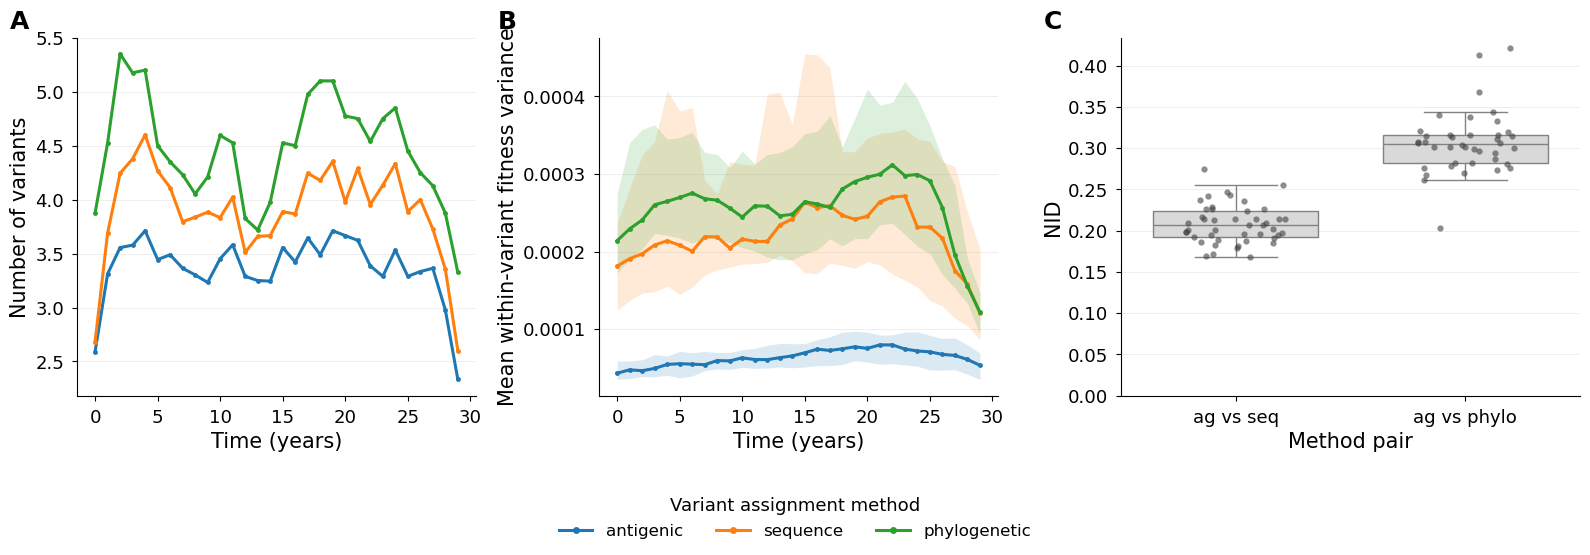

saved figureS4_candidates_panel.{pdf,png}  [panel B: host_immunity_variance_over_time.csv, n=42; panels A/C: n=45]


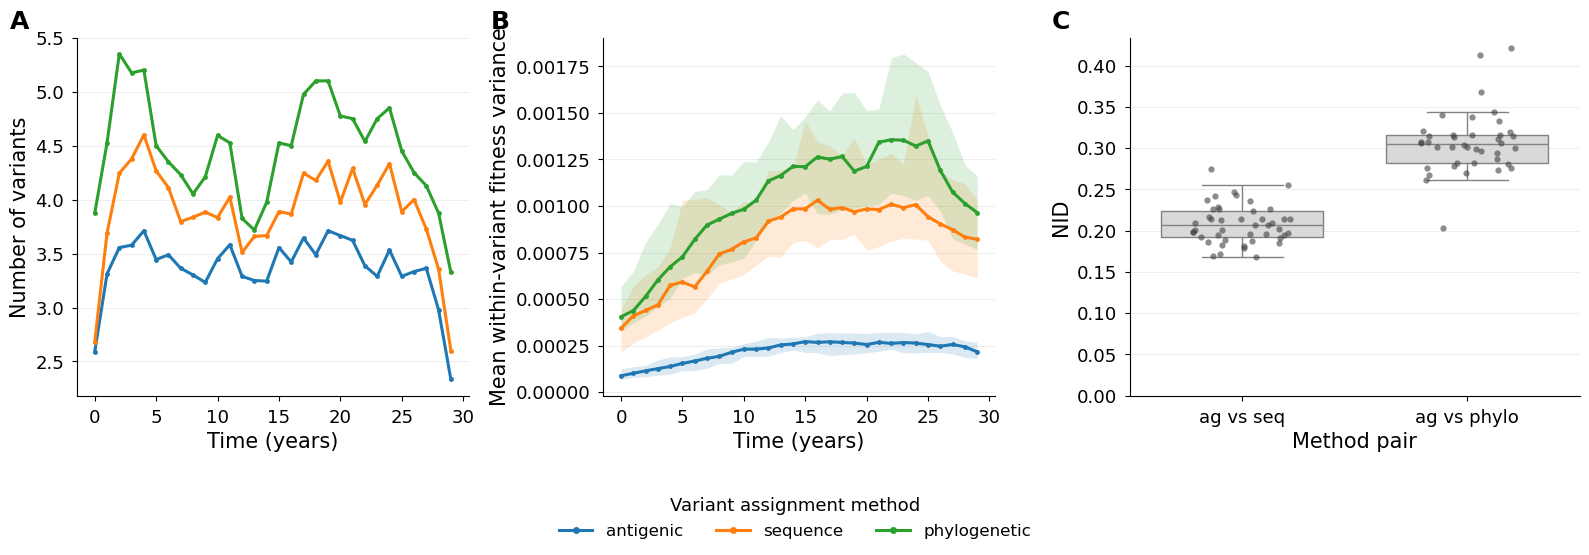

saved figureS4_candidates_panel-centroids.{pdf,png}  [panel B: fitness_variance_over_time.csv, n=45; panels A/C: n=45]
-> /Users/zo/projects/research/antigen-tex/reviews/round1/figures


In [5]:
# ======================================================================
# Figure S4 (flu-like candidates). Caption:
#
#   Method comparison across the flu-like candidate simulations.
#   (A) Number of variants over time, per assignment method (line = across-run
#       mean; counts are integer-valued, so no spread band is shown). (B) Average
#       within-variant fitness variance over time (line = across-run median;
#       band = IQR). The median is used because the per-run variance is
#       right-skewed, which would push the mean outside its own IQR. (C)
#       Distribution of the normalized information distance (NID) between the antigenic
#       ground-truth partition and each other method across runs (0 = identical partition, 1 = independent).
#   All three methods track a stable ~3-5 variants and the same variance
#       ordering (phylogenetic > sequence > antigenic), supporting the claim
#       that results are stable when simulating a flu-like tree.
#
# Panel B is drawn once per fitness model (see VARIANCE_SOURCES): the per-host
# immune-history model to the default filename, and the centroid approximation
# to a '-centroids' variant. Panels A and C are identical between them.
# ======================================================================


def build_figure(variance_df):
    """Build the three-panel figure with the given panel-B fitness variance."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8),
                             gridspec_kw={'width_ratios': [1, 1, 1.15]})

    time_panel(axes[0], counts_df, 'n_variants', 'year_bin', 'Number of variants',
               center='mean', band=COUNTS_BAND)
    time_panel(axes[1], variance_df, 'mean_variance', 'year', 'Mean within-variant fitness variance',
               center='median', band=True)
    nid_panel(axes[2], nid_df)

    # Shared method legend under the panels (no scatter panels above them now).
    handles = [mlines.Line2D([], [], color=METHOD_COLORS[m], marker='o', ms=5, lw=2.2,
                             label=METHOD_LABELS[m]) for m in METHODS]
    fig.legend(handles=handles, title='Variant assignment method', ncol=3,
               loc='lower center', bbox_to_anchor=(0.5, -0.12), frameon=False)

    fig.tight_layout(rect=(0, 0.06, 1, 1))

    add_panel_letters(fig, axes, 'ABC')
    return fig


FIG_DIR.mkdir(parents=True, exist_ok=True)
for suffix, variance_df in variance_dfs.items():
    source_file = VARIANCE_SOURCES[suffix][0]
    n_variance = variance_df.groupby(['config', 'run']).ngroups
    stem = f'figureS4_candidates_panel{suffix}'

    fig = build_figure(variance_df)
    for ext in ('pdf', 'png'):
        fig.savefig(FIG_DIR / f'{stem}.{ext}', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'saved {stem}.{{pdf,png}}  '
          f'[panel B: {source_file}, n={n_variance}; panels A/C: n={N_RUNS}]')
print('->', FIG_DIR.resolve())